In [12]:
# Install CUDA-enabled PyTorch (for NVIDIA GPU support)
# First uninstall CPU version, then install CUDA version
%pip uninstall torch torchvision torchaudio -y
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --quiet
%pip install monai monai-generative --quiet

Found existing installation: torch 2.8.0
Uninstalling torch-2.8.0:
  Successfully uninstalled torch-2.8.0
Found existing installation: torchvision 0.23.0
Uninstalling torchvision-0.23.0:
  Successfully uninstalled torchvision-0.23.0
Found existing installation: torchaudio 2.8.0
Uninstalling torchaudio-2.8.0:
  Successfully uninstalled torchaudio-2.8.0
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# Restart the kernel to use newly installed CUDA PyTorch
# Run this cell, then RESTART THE KERNEL manually (Ctrl+Shift+P -> "Restart Kernel")
import IPython
print("Please RESTART THE KERNEL now to use CUDA-enabled PyTorch!")
print("Press Ctrl+Shift+P and type 'Restart Kernel' or click the restart button in the toolbar.")
print("\nAfter restarting, skip this cell and run from Cell 3 onwards.")

Please RESTART THE KERNEL now to use CUDA-enabled PyTorch!
Press Ctrl+Shift+P and type 'Restart Kernel' or click the restart button in the toolbar.

After restarting, skip this cell and run from Cell 3 onwards.


In [1]:
# Import required libraries
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# MONAI imports
from monai.utils import set_determinism
from generative.networks.nets import DiffusionModelUNet
from generative.networks.schedulers import DDPMScheduler, DDIMScheduler
from generative.inferers import DiffusionInferer

# Check CUDA availability and set device
print("=" * 50)
print("GPU/CUDA STATUS CHECK")
print("=" * 50)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU count: {torch.cuda.device_count()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = torch.device("cuda")
else:
    print("\nWARNING: CUDA not available! Training will be SLOW on CPU.")
    print("Make sure you have NVIDIA GPU drivers and CUDA-enabled PyTorch installed.")
    print("\nTo install CUDA-enabled PyTorch, run:")
    print("  pip uninstall torch torchvision")
    print("  pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121")
    device = torch.device("cpu")

print(f"\nUsing device: {device}")
print("=" * 50)

# Set determinism for reproducibility
set_determinism(seed=42)

GPU/CUDA STATUS CHECK
PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU
GPU memory: 8.59 GB

Using device: cuda


c:\Users\R K Raman\AppData\Local\Programs\Python\Python311\Lib\site-packages\generative\networks\layers\vector_quantizer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
c:\Users\R K Raman\AppData\Local\Programs\Python\Python311\Lib\site-packages\generative\networks\layers\vector_quantizer.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


## Extract ZIP Datasets and Load Images

Uses torchvision's `DatasetFolder` to directly load images from the extracted ZIP files.

In [2]:
# Define paths for local Windows execution
import os

# Use the actual path where your notebook and ZIP files are located
DATA_DIR = Path(r"c:\Pranav Aditya\MP01")
CT_SCANS_ZIP = DATA_DIR / "CT SCANS.zip"
KIDNEY_ZIP = DATA_DIR / "KIDNEY.zip"
EXTRACTED_DIR = DATA_DIR / "extracted_data"

print(f"Data directory: {DATA_DIR}")
print(f"CT SCANS ZIP exists: {CT_SCANS_ZIP.exists()}")
print(f"KIDNEY ZIP exists: {KIDNEY_ZIP.exists()}")

# Create extraction directory
EXTRACTED_DIR.mkdir(exist_ok=True, parents=True)

# Extract ZIP files
def extract_zip(zip_path, extract_to):
    """Extract ZIP file to specified directory"""
    extract_folder = extract_to / zip_path.stem
    if not extract_folder.exists():
        print(f"Extracting {zip_path.name}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_folder)
        print(f"Extracted to {extract_folder}")
    else:
        print(f"{zip_path.name} already extracted")
    return extract_folder

# Extract both datasets
ct_scans_dir = extract_zip(CT_SCANS_ZIP, EXTRACTED_DIR)
kidney_dir = extract_zip(KIDNEY_ZIP, EXTRACTED_DIR)

print(f"\nCT Scans directory: {ct_scans_dir}")
print(f"Kidney directory: {kidney_dir}")

# List contents to understand structure
print("\nCT Scans contents:", list(ct_scans_dir.iterdir())[:5])
print("Kidney contents:", list(kidney_dir.iterdir())[:5])

Data directory: c:\Pranav Aditya\MP01
CT SCANS ZIP exists: True
KIDNEY ZIP exists: True
CT SCANS.zip already extracted
KIDNEY.zip already extracted

CT Scans directory: c:\Pranav Aditya\MP01\extracted_data\CT SCANS
Kidney directory: c:\Pranav Aditya\MP01\extracted_data\KIDNEY

CT Scans contents: [WindowsPath('c:/Pranav Aditya/MP01/extracted_data/CT SCANS/Breast Cancer'), WindowsPath('c:/Pranav Aditya/MP01/extracted_data/CT SCANS/Chest CT-Scan images Dataset'), WindowsPath('c:/Pranav Aditya/MP01/extracted_data/CT SCANS/Computed Tomography (CT) of the Brain'), WindowsPath('c:/Pranav Aditya/MP01/extracted_data/CT SCANS/Dental OPG Xray Dataset'), WindowsPath('c:/Pranav Aditya/MP01/extracted_data/CT SCANS/Digitally Reconstructed Radiographs (DRR) - Bones')]
Kidney contents: [WindowsPath('c:/Pranav Aditya/MP01/extracted_data/KIDNEY/data')]


In [3]:
# Configuration
IMAGE_SIZE = 64  # Image size for training
BATCH_SIZE = 8
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
NUM_TRAIN_TIMESTEPS = 1000

# Define transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalize to [-1, 1]
])

# Use ImageFolder to load from extracted directories
# Combine both datasets by creating a ConcatDataset
from torch.utils.data import ConcatDataset
from torchvision.datasets import ImageFolder

# Helper function to find the image folder
def find_image_folder(base_dir):
    """Find folder containing images (handles nested structures)"""
    base_dir = Path(base_dir)
    # Check if images are directly in base_dir
    image_exts = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif'}
    
    # Search for folders with images
    for folder in [base_dir] + list(base_dir.rglob('*')):
        if folder.is_dir():
            files = list(folder.iterdir())
            if any(f.suffix.lower() in image_exts for f in files if f.is_file()):
                return folder
    return base_dir

# Find actual image directories
ct_image_dir = find_image_folder(ct_scans_dir)
kidney_image_dir = find_image_folder(kidney_dir)

print(f"CT images folder: {ct_image_dir}")
print(f"Kidney images folder: {kidney_image_dir}")

# Create datasets using ImageFolder
# ImageFolder expects subfolders, so we'll use a workaround with DatasetFolder
from torchvision.datasets import DatasetFolder
from PIL import Image

def image_loader(path):
    return Image.open(path).convert('L')

IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif')

# Create dataset from directories
ct_dataset = DatasetFolder(
    root=ct_image_dir.parent if ct_image_dir.name not in ['train', 'test', 'val'] else ct_image_dir.parent.parent,
    loader=image_loader,
    extensions=IMG_EXTENSIONS,
    transform=train_transforms
)

kidney_dataset = DatasetFolder(
    root=kidney_image_dir.parent if kidney_image_dir.name not in ['train', 'test', 'val'] else kidney_image_dir.parent.parent,
    loader=image_loader,
    extensions=IMG_EXTENSIONS,
    transform=train_transforms
)

# Combine datasets
combined_dataset = ConcatDataset([ct_dataset, kidney_dataset])

# Create dataloader
dataloader = DataLoader(combined_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

print(f"\nCT Dataset size: {len(ct_dataset)}")
print(f"Kidney Dataset size: {len(kidney_dataset)}")
print(f"Combined Dataset size: {len(combined_dataset)}")
print(f"Number of batches: {len(dataloader)}")

CT images folder: c:\Pranav Aditya\MP01\extracted_data\CT SCANS\Breast Cancer\Breast Cancer\0\3D_Rendering
Kidney images folder: c:\Pranav Aditya\MP01\extracted_data\KIDNEY\data\Cyst\3D_Rendering

CT Dataset size: 20397
Kidney Dataset size: 48217
Combined Dataset size: 68614
Number of batches: 8577


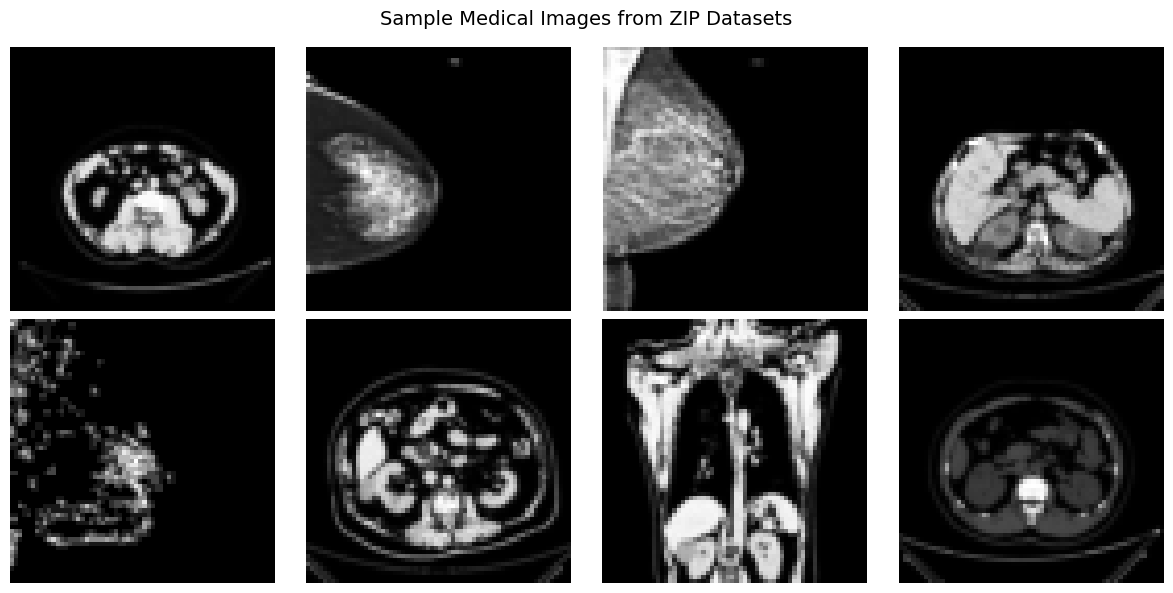

In [4]:
# Visualize sample images from dataset
def visualize_samples(dataloader, num_samples=8):
    """Visualize sample images from the dataset"""
    batch = next(iter(dataloader))
    images = batch[0]  # DatasetFolder returns (image, label) tuple
    
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            img = images[i].squeeze().cpu().numpy()
            # Denormalize from [-1, 1] to [0, 1]
            img = (img + 1) / 2
            ax.imshow(img, cmap='gray')
            ax.axis('off')
    plt.suptitle('Sample Medical Images from ZIP Datasets', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_samples(dataloader)

## Define the Diffusion Model (UNet)

In [5]:
# Create the Diffusion UNet Model
model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    num_channels=(64, 128, 256, 256),
    attention_levels=(False, False, True, True),
    num_res_blocks=2,
    num_head_channels=64,
)
model = model.to(device)

# Count parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")

# Create the noise scheduler (DDPM)
scheduler = DDPMScheduler(
    num_train_timesteps=NUM_TRAIN_TIMESTEPS,
    schedule="linear_beta",
    beta_start=0.0015,
    beta_end=0.0195,
)

# Create the diffusion inferer
inferer = DiffusionInferer(scheduler)

print("Model and scheduler created successfully!")

Model parameters: 26,621,057
Model and scheduler created successfully!


## Training Loop

In [6]:
# Setup optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Training function
def train_epoch(model, dataloader, optimizer, scheduler, device):
    """Train for one epoch"""
    model.train()
    epoch_loss = 0
    
    progress_bar = tqdm(dataloader, desc="Training")
    for batch in progress_bar:
        images = batch[0].to(device)  # DatasetFolder returns (image, label)
        
        optimizer.zero_grad()
        
        # Sample random timesteps
        timesteps = torch.randint(
            0, scheduler.num_train_timesteps, 
            (images.shape[0],), 
            device=device
        ).long()
        
        # Sample noise
        noise = torch.randn_like(images).to(device)
        
        # Get noisy images
        noisy_images = scheduler.add_noise(original_samples=images, noise=noise, timesteps=timesteps)
        
        # Predict noise
        noise_pred = model(x=noisy_images, timesteps=timesteps)
        
        # Compute loss
        loss = F.mse_loss(noise_pred, noise)
        
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())
    
    return epoch_loss / len(dataloader)

print("Training function defined!")

Training function defined!


In [7]:
# Sample generation function
@torch.no_grad()
def generate_samples(model, scheduler, num_samples=8, image_size=64, device="cuda"):
    """Generate samples using the trained model"""
    model.eval()
    
    # Start from random noise
    noise = torch.randn(num_samples, 1, image_size, image_size).to(device)
    
    # Create DDIM scheduler for faster sampling
    ddim_scheduler = DDIMScheduler(
        num_train_timesteps=NUM_TRAIN_TIMESTEPS,
        schedule="linear_beta",
        beta_start=0.0015,
        beta_end=0.0195,
    )
    ddim_scheduler.set_timesteps(num_inference_steps=50)  # Faster inference
    
    sample = noise
    for t in tqdm(ddim_scheduler.timesteps, desc="Generating"):
        # Get model prediction
        noise_pred = model(x=sample, timesteps=torch.tensor([t]).to(device).expand(num_samples))
        
        # Update sample
        sample, _ = ddim_scheduler.step(noise_pred, t, sample)
    
    return sample

print("Generation function defined!")

Generation function defined!


Starting training for 100 epochs...
Training on 68614 images with batch size 8
--------------------------------------------------


Training: 100%|██████████| 8577/8577 [30:05<00:00,  4.75it/s, loss=0.013]   


Epoch [1/100] - Loss: 0.020438 - LR: 0.000100


Training: 100%|██████████| 8577/8577 [18:34<00:00,  7.69it/s, loss=0.00987] 


Epoch [2/100] - Loss: 0.013328 - LR: 0.000100


...

Training: 100%|██████████| 8577/8577 [18:24<00:00,  7.77it/s, loss=0.00164] 


Epoch [9/100] - Loss: 0.008275 - LR: 0.000098


Training: 100%|██████████| 8577/8577 [18:34<00:00,  7.70it/s, loss=0.000971]


Epoch [10/100] - Loss: 0.008103 - LR: 0.000098


Generating: 100%|██████████| 50/50 [00:01<00:00, 40.69it/s]


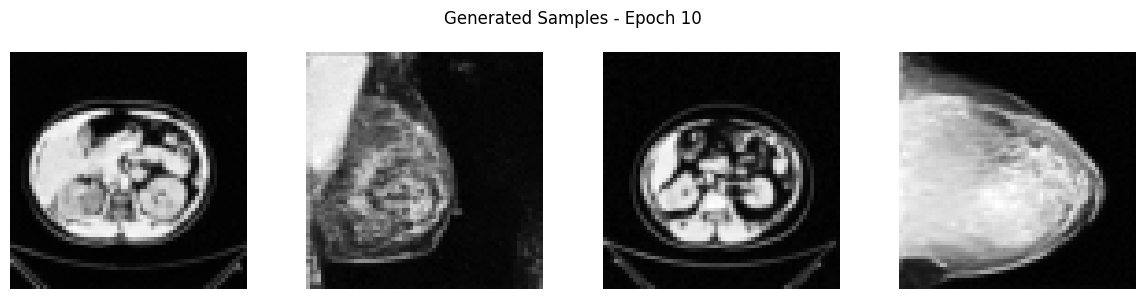

Training: 100%|██████████| 8577/8577 [18:35<00:00,  7.69it/s, loss=0.00462] 


Epoch [11/100] - Loss: 0.007885 - LR: 0.000097


Training: 100%|██████████| 8577/8577 [18:36<00:00,  7.68it/s, loss=0.00439] 


Epoch [12/100] - Loss: 0.007802 - LR: 0.000096


Training: 100%|██████████| 8577/8577 [18:35<00:00,  7.69it/s, loss=0.00232] 


...

Training: 100%|██████████| 8577/8577 [18:40<00:00,  7.66it/s, loss=0.00645] 


Epoch [19/100] - Loss: 0.006759 - LR: 0.000091


Training: 100%|██████████| 8577/8577 [18:42<00:00,  7.64it/s, loss=0.00467] 


Epoch [20/100] - Loss: 0.006811 - LR: 0.000090


Generating: 100%|██████████| 50/50 [00:01<00:00, 46.52it/s]


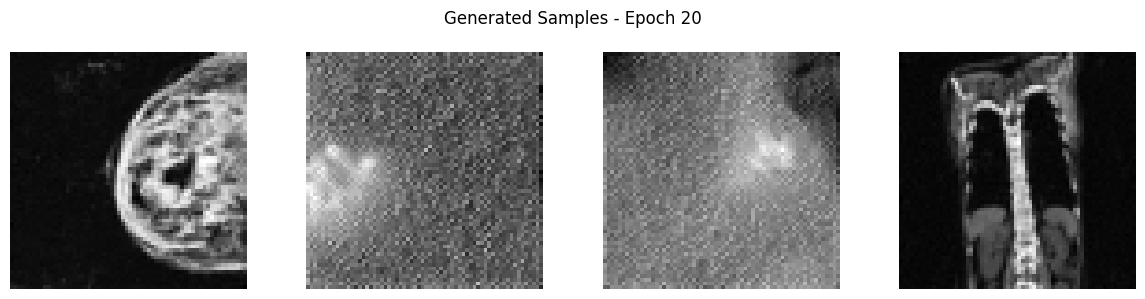

Training: 100%|██████████| 8577/8577 [18:30<00:00,  7.72it/s, loss=0.0178]  


Epoch [21/100] - Loss: 0.006722 - LR: 0.000090


Training: 100%|██████████| 8577/8577 [18:30<00:00,  7.72it/s, loss=0.00292] 


Epoch [22/100] - Loss: 0.006593 - LR: 0.000089


Training: 100%|██████████| 8577/8577 [18:34<00:00,  7.70it/s, loss=0.00499] 


...

Training: 100%|██████████| 8577/8577 [18:30<00:00,  7.72it/s, loss=0.00882] 


Epoch [29/100] - Loss: 0.006129 - LR: 0.000081


Training: 100%|██████████| 8577/8577 [18:33<00:00,  7.71it/s, loss=0.036]   


Epoch [30/100] - Loss: 0.006043 - LR: 0.000079


Generating: 100%|██████████| 50/50 [00:01<00:00, 45.76it/s]


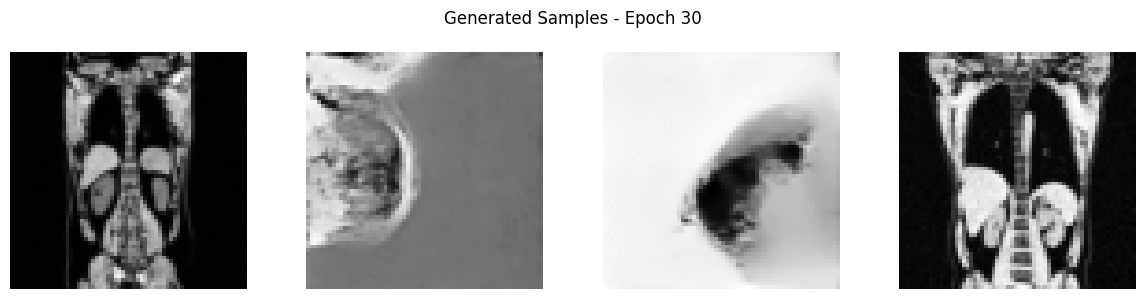

Training: 100%|██████████| 8577/8577 [18:45<00:00,  7.62it/s, loss=0.00736] 


Epoch [31/100] - Loss: 0.006023 - LR: 0.000078


Training: 100%|██████████| 8577/8577 [18:45<00:00,  7.62it/s, loss=0.00462] 


Epoch [32/100] - Loss: 0.005848 - LR: 0.000077


Training: 100%|██████████| 8577/8577 [18:47<00:00,  7.61it/s, loss=0.0041]  


...

Training: 100%|██████████| 8577/8577 [18:57<00:00,  7.54it/s, loss=0.000998]


Epoch [39/100] - Loss: 0.005535 - LR: 0.000067


Training: 100%|██████████| 8577/8577 [18:32<00:00,  7.71it/s, loss=0.00769] 


Epoch [40/100] - Loss: 0.005414 - LR: 0.000065


Generating: 100%|██████████| 50/50 [00:01<00:00, 45.83it/s]


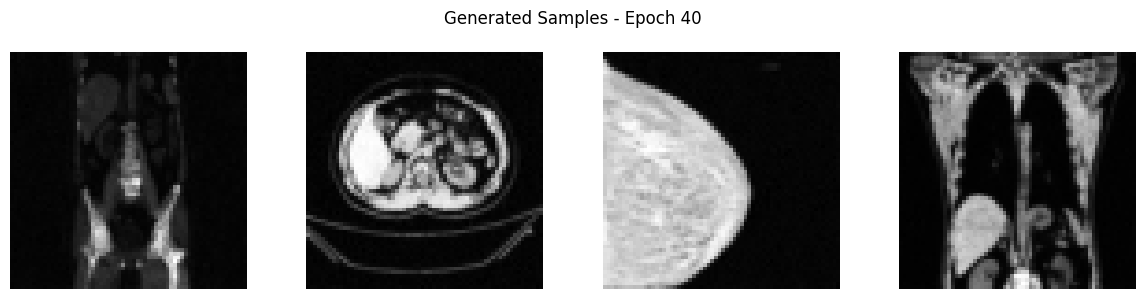

Training: 100%|██████████| 8577/8577 [18:42<00:00,  7.64it/s, loss=0.00459] 


Epoch [41/100] - Loss: 0.005455 - LR: 0.000064


Training: 100%|██████████| 8577/8577 [18:32<00:00,  7.71it/s, loss=0.00296] 


Epoch [42/100] - Loss: 0.005295 - LR: 0.000062


Training: 100%|██████████| 8577/8577 [18:42<00:00,  7.64it/s, loss=0.00313] 


...

Training: 100%|██████████| 8577/8577 [17:53<00:00,  7.99it/s, loss=0.0063]  


Epoch [49/100] - Loss: 0.005020 - LR: 0.000052


Training: 100%|██████████| 8577/8577 [18:52<00:00,  7.57it/s, loss=0.00221] 


Epoch [50/100] - Loss: 0.004984 - LR: 0.000050


Generating: 100%|██████████| 50/50 [00:01<00:00, 44.77it/s]


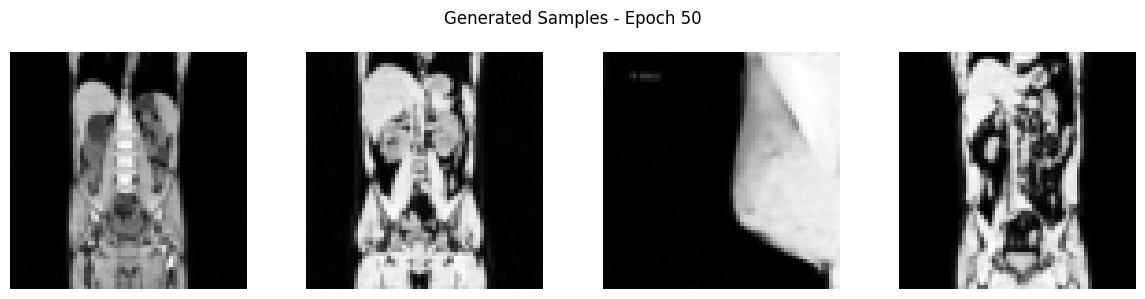

Training: 100%|██████████| 8577/8577 [18:02<00:00,  7.93it/s, loss=0.00256] 


Epoch [51/100] - Loss: 0.005064 - LR: 0.000048


Training: 100%|██████████| 8577/8577 [19:20<00:00,  7.39it/s, loss=0.00515] 


Epoch [52/100] - Loss: 0.004869 - LR: 0.000047


Training: 100%|██████████| 8577/8577 [17:44<00:00,  8.05it/s, loss=0.00507] 


...

Training: 100%|██████████| 8577/8577 [18:05<00:00,  7.90it/s, loss=0.00302] 


Epoch [59/100] - Loss: 0.004692 - LR: 0.000036


Training: 100%|██████████| 8577/8577 [18:01<00:00,  7.93it/s, loss=0.00704] 


Epoch [60/100] - Loss: 0.004597 - LR: 0.000035


Generating: 100%|██████████| 50/50 [00:01<00:00, 44.48it/s]


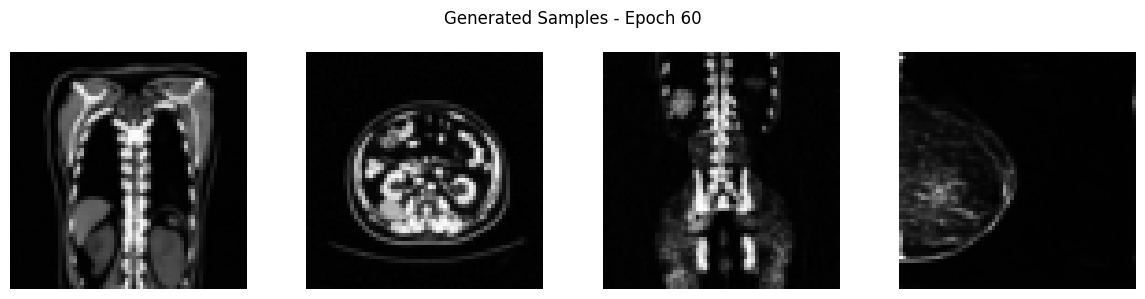

Training: 100%|██████████| 8577/8577 [18:19<00:00,  7.80it/s, loss=0.00288] 


Epoch [61/100] - Loss: 0.004536 - LR: 0.000033


Training: 100%|██████████| 8577/8577 [18:42<00:00,  7.64it/s, loss=0.00609] 


Epoch [62/100] - Loss: 0.004395 - LR: 0.000032


Training: 100%|██████████| 8577/8577 [18:32<00:00,  7.71it/s, loss=0.00215] 


...

Training: 100%|██████████| 8577/8577 [18:06<00:00,  7.89it/s, loss=0.00389] 


Epoch [69/100] - Loss: 0.004216 - LR: 0.000022


Training: 100%|██████████| 8577/8577 [18:18<00:00,  7.81it/s, loss=0.0017]  


Epoch [70/100] - Loss: 0.004238 - LR: 0.000021


Generating: 100%|██████████| 50/50 [00:01<00:00, 43.83it/s]


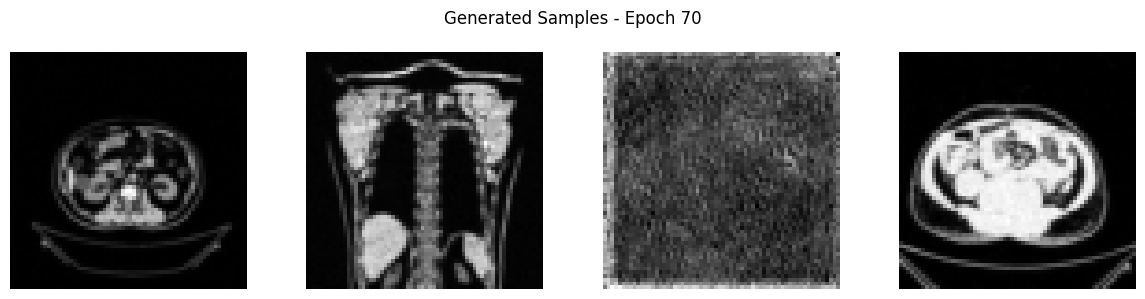

Training: 100%|██████████| 8577/8577 [18:00<00:00,  7.94it/s, loss=0.00784] 


Epoch [71/100] - Loss: 0.004064 - LR: 0.000019


Training: 100%|██████████| 8577/8577 [18:09<00:00,  7.87it/s, loss=0.0022]  


Epoch [72/100] - Loss: 0.004067 - LR: 0.000018


Training: 100%|██████████| 8577/8577 [21:53<00:00,  6.53it/s, loss=0.00856] 


...

Training: 100%|██████████| 8577/8577 [19:34<00:00,  7.30it/s, loss=0.00336] 


Epoch [79/100] - Loss: 0.003808 - LR: 0.000010


Training: 100%|██████████| 8577/8577 [20:20<00:00,  7.03it/s, loss=0.000837]


Epoch [80/100] - Loss: 0.003818 - LR: 0.000010


Generating: 100%|██████████| 50/50 [00:01<00:00, 46.08it/s]


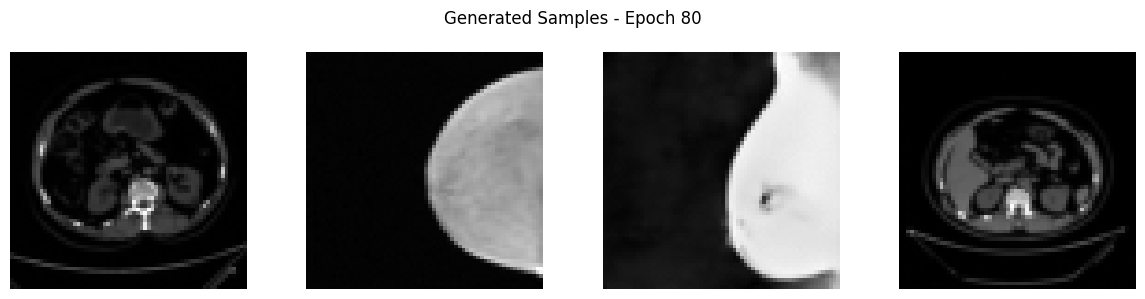

Training: 100%|██████████| 8577/8577 [19:11<00:00,  7.45it/s, loss=0.000653]


Epoch [81/100] - Loss: 0.003849 - LR: 0.000009


Training: 100%|██████████| 8577/8577 [18:24<00:00,  7.77it/s, loss=0.00222] 


Epoch [82/100] - Loss: 0.003729 - LR: 0.000008


Training: 100%|██████████| 8577/8577 [18:17<00:00,  7.81it/s, loss=0.0383]  


...

Training: 100%|██████████| 8577/8577 [18:42<00:00,  7.64it/s, loss=0.000499]


Epoch [89/100] - Loss: 0.003621 - LR: 0.000003


Training: 100%|██████████| 8577/8577 [18:29<00:00,  7.73it/s, loss=0.00201] 


Epoch [90/100] - Loss: 0.003594 - LR: 0.000002


Generating: 100%|██████████| 50/50 [00:01<00:00, 44.42it/s]


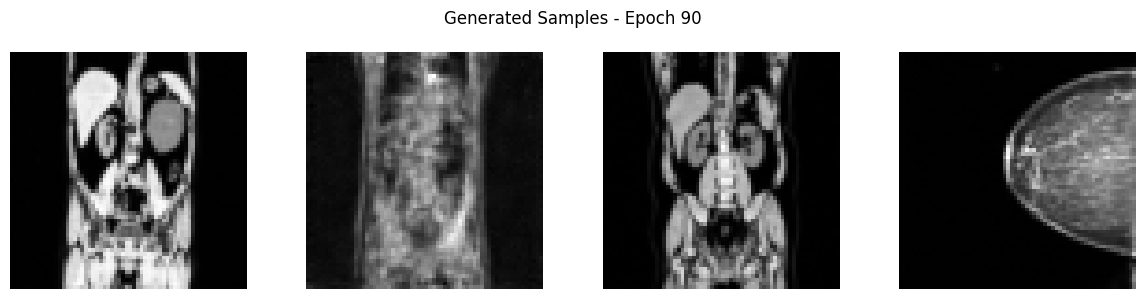

Training: 100%|██████████| 8577/8577 [18:32<00:00,  7.71it/s, loss=0.00515] 


Epoch [91/100] - Loss: 0.003536 - LR: 0.000002


Training: 100%|██████████| 8577/8577 [18:49<00:00,  7.60it/s, loss=0.00226] 


Epoch [92/100] - Loss: 0.003552 - LR: 0.000002


Training: 100%|██████████| 8577/8577 [18:43<00:00,  7.64it/s, loss=0.00293] 


...

Training: 100%|██████████| 8577/8577 [18:41<00:00,  7.65it/s, loss=0.00884] 


Epoch [99/100] - Loss: 0.003489 - LR: 0.000000


Training: 100%|██████████| 8577/8577 [18:45<00:00,  7.62it/s, loss=0.00188] 


Epoch [100/100] - Loss: 0.003479 - LR: 0.000000


Generating: 100%|██████████| 50/50 [00:01<00:00, 45.17it/s]


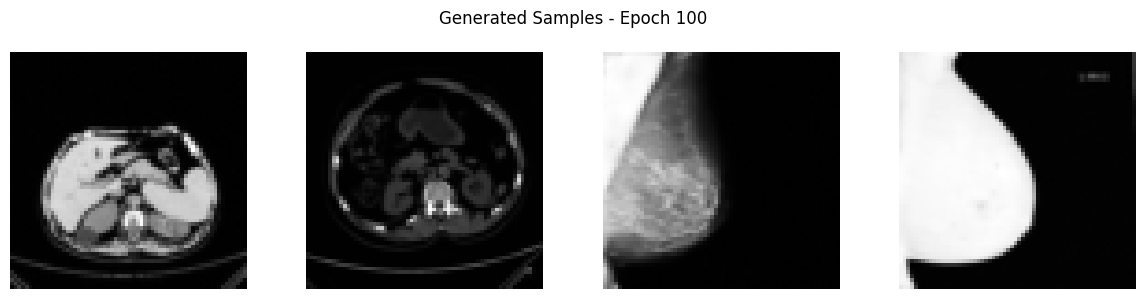


Training completed!
Best loss: 0.003410


In [8]:
# Training loop
losses = []
best_loss = float('inf')

print(f"Starting training for {NUM_EPOCHS} epochs...")
print(f"Training on {len(combined_dataset)} images with batch size {BATCH_SIZE}")
print("-" * 50)

for epoch in range(NUM_EPOCHS):
    epoch_loss = train_epoch(model, dataloader, optimizer, scheduler, device)
    losses.append(epoch_loss)
    
    lr_scheduler.step()
    
    # Save best model
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_loss,
        }, DATA_DIR / 'best_diffusion_model.pth')
    
    # Print progress
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] - Loss: {epoch_loss:.6f} - LR: {lr_scheduler.get_last_lr()[0]:.6f}")
    
    # Generate samples every 10 epochs
    if (epoch + 1) % 10 == 0:
        samples = generate_samples(model, scheduler, num_samples=4, image_size=IMAGE_SIZE, device=device)
        
        fig, axes = plt.subplots(1, 4, figsize=(12, 3))
        for i, ax in enumerate(axes):
            img = samples[i].squeeze().cpu().numpy()
            img = (img + 1) / 2  # Denormalize
            img = np.clip(img, 0, 1)
            ax.imshow(img, cmap='gray')
            ax.axis('off')
        plt.suptitle(f'Generated Samples - Epoch {epoch+1}')
        plt.tight_layout()
        plt.show()

print("\nTraining completed!")
print(f"Best loss: {best_loss:.6f}")

## Training Loss Visualization

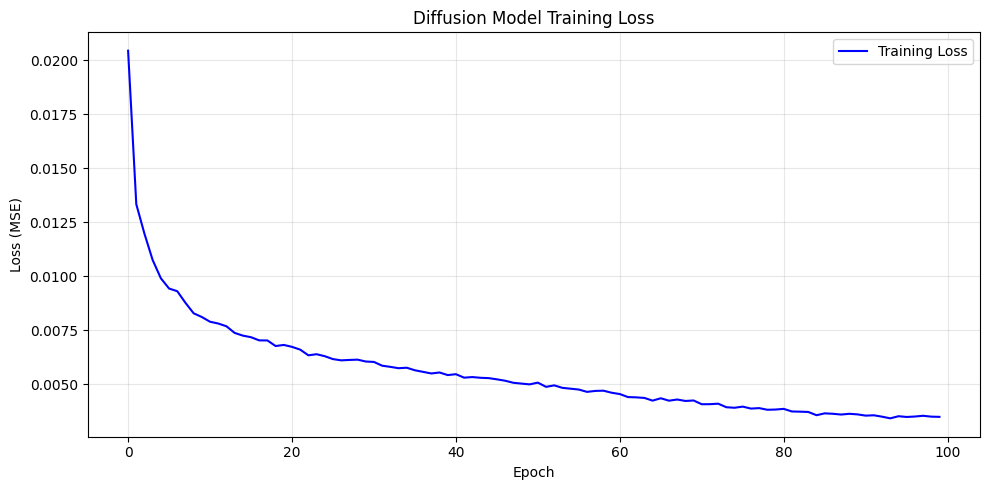

Final training loss: 0.003479


In [9]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Diffusion Model Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_DIR / 'training_loss.png', dpi=150)
plt.show()

print(f"Final training loss: {losses[-1]:.6f}")

## Generate New Medical Images

In [10]:
# Load best model for inference
checkpoint = torch.load(DATA_DIR / 'best_diffusion_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1} with loss {checkpoint['loss']:.6f}")

C:\Users\R K Raman\AppData\Local\Temp\ipykernel_29672\3669526832.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(DATA_DIR / 'best_diffusion_model

Loaded best model from epoch 94 with loss 0.003410


Generating 16 new medical images...


Generating: 100%|██████████| 50/50 [00:02<00:00, 17.25it/s]


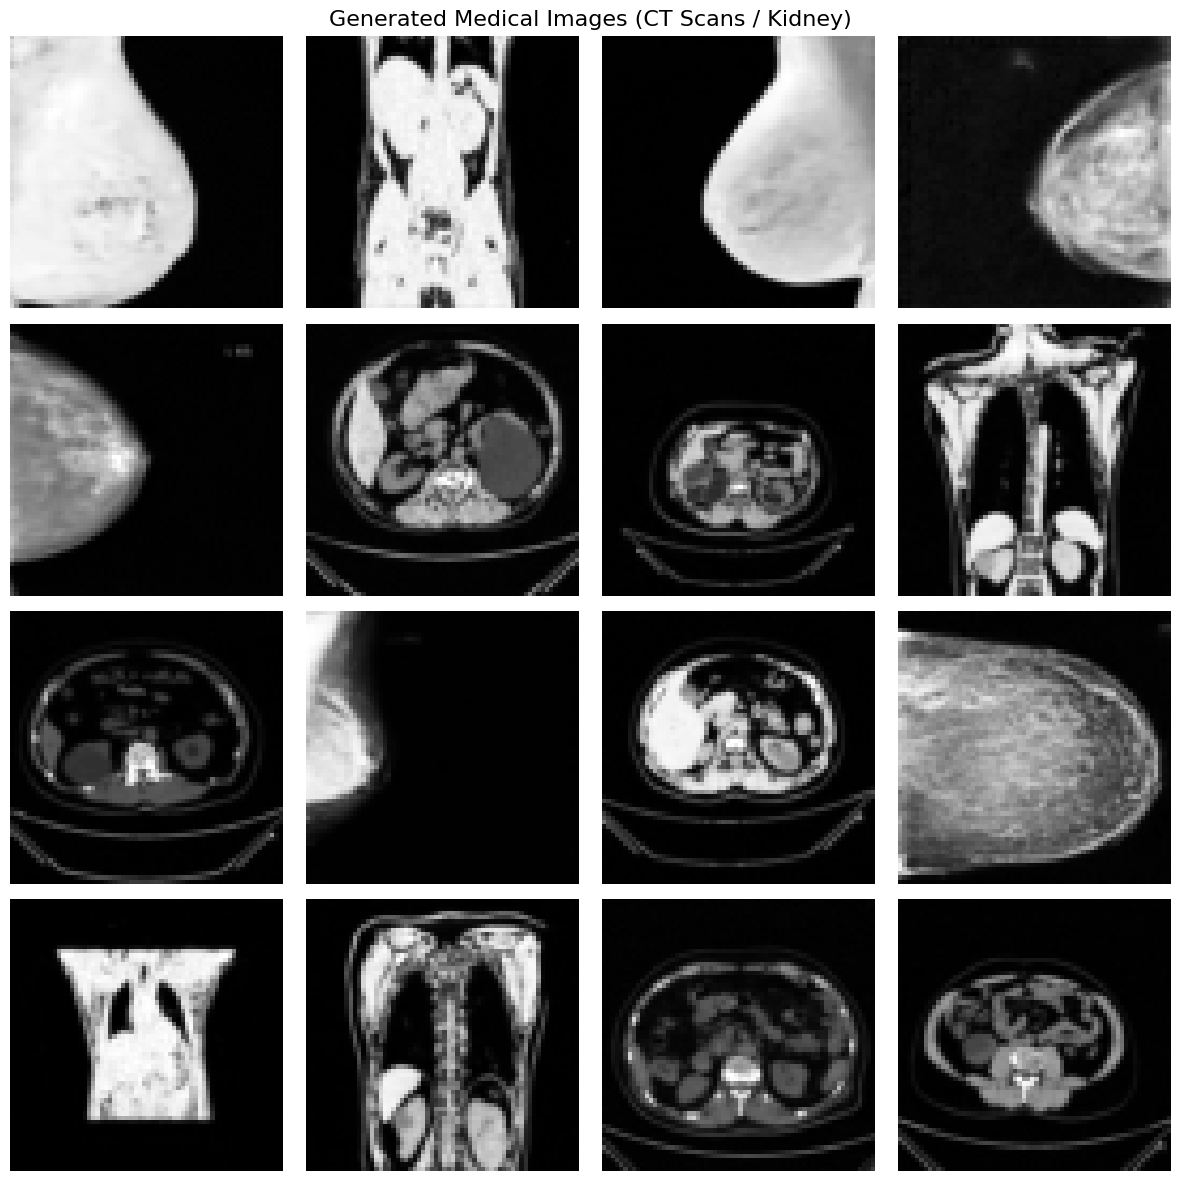

Generated images saved to 'generated_samples.png'


In [11]:
# Generate a grid of new medical images
NUM_GENERATED = 16

print(f"Generating {NUM_GENERATED} new medical images...")
generated_images = generate_samples(model, scheduler, num_samples=NUM_GENERATED, image_size=IMAGE_SIZE, device=device)

# Plot generated images
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img = generated_images[i].squeeze().cpu().numpy()
    img = (img + 1) / 2  # Denormalize to [0, 1]
    img = np.clip(img, 0, 1)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.suptitle('Generated Medical Images (CT Scans / Kidney)', fontsize=16)
plt.tight_layout()
plt.savefig(DATA_DIR / 'generated_samples.png', dpi=150)
plt.show()

print("Generated images saved to 'generated_samples.png'")

## Compare Real vs Generated Images

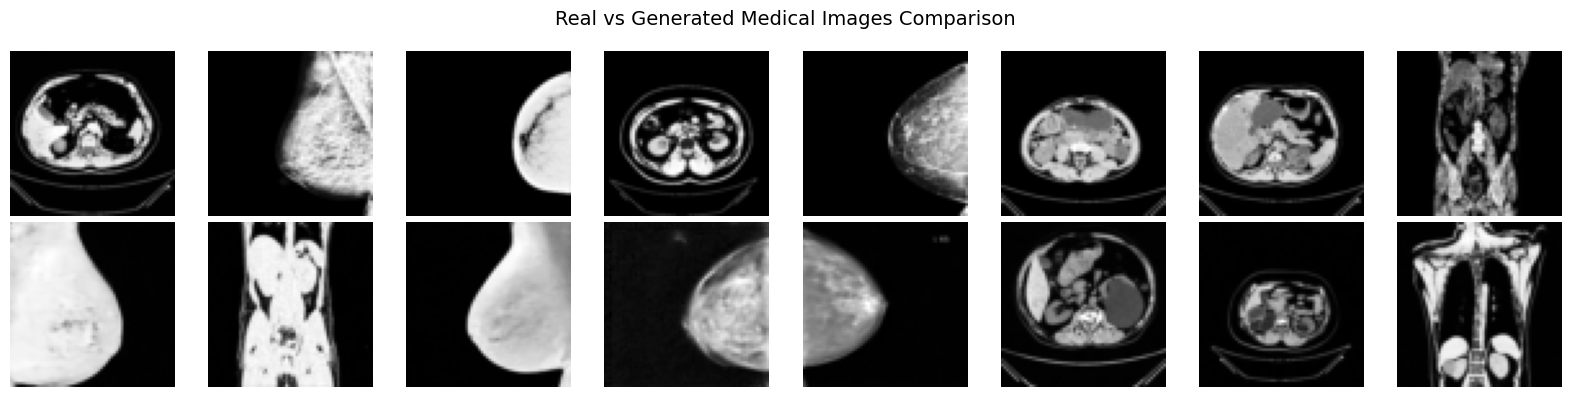

In [12]:
# Side-by-side comparison of real and generated images
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

# Get real images
real_batch = next(iter(dataloader))
real_images = real_batch[0]  # DatasetFolder returns (image, label)

# Top row: Real images
axes[0, 0].set_ylabel('Real', fontsize=12)
for i in range(8):
    if i < len(real_images):
        img = real_images[i].squeeze().cpu().numpy()
        img = (img + 1) / 2
        axes[0, i].imshow(img, cmap='gray')
    axes[0, i].axis('off')

# Bottom row: Generated images
axes[1, 0].set_ylabel('Generated', fontsize=12)
for i in range(8):
    img = generated_images[i].squeeze().cpu().numpy()
    img = (img + 1) / 2
    img = np.clip(img, 0, 1)
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].axis('off')

plt.suptitle('Real vs Generated Medical Images Comparison', fontsize=14)
plt.tight_layout()
plt.savefig(DATA_DIR / 'comparison.png', dpi=150)
plt.show()

## Save and Export Model

In [13]:
# Save the final model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_config': {
        'num_train_timesteps': NUM_TRAIN_TIMESTEPS,
        'beta_start': 0.0015,
        'beta_end': 0.0195,
    },
    'image_size': IMAGE_SIZE,
    'num_epochs': NUM_EPOCHS,
    'final_loss': losses[-1] if losses else None,
    'losses': losses,
}, DATA_DIR / 'final_diffusion_model.pth')

print("Model saved successfully!")
print(f"\nModel files saved:")
print(f"  - best_diffusion_model.pth (best checkpoint)")
print(f"  - final_diffusion_model.pth (final model)")
print(f"  - training_loss.png (loss plot)")
print(f"  - generated_samples.png (sample outputs)")
print(f"  - comparison.png (real vs generated)")

Model saved successfully!

Model files saved:
  - best_diffusion_model.pth (best checkpoint)
  - final_diffusion_model.pth (final model)
  - training_loss.png (loss plot)
  - generated_samples.png (sample outputs)
  - comparison.png (real vs generated)


## Inference Function (Generate on Demand)

In [14]:
def load_and_generate(model_path, num_images=4, inference_steps=50):
    """
    Load a saved model and generate new medical images.
    
    Args:
        model_path: Path to saved model checkpoint
        num_images: Number of images to generate
        inference_steps: Number of DDIM inference steps (more = better quality, slower)
    
    Returns:
        Generated images as numpy array
    """
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    
    # Create model
    loaded_model = DiffusionModelUNet(
        spatial_dims=2,
        in_channels=1,
        out_channels=1,
        num_channels=(64, 128, 256, 256),
        attention_levels=(False, False, True, True),
        num_res_blocks=2,
        num_head_channels=64,
    ).to(device)
    
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.eval()
    
    # Get config
    config = checkpoint.get('scheduler_config', {})
    img_size = checkpoint.get('image_size', 64)
    
    # Create scheduler
    ddim_scheduler = DDIMScheduler(
        num_train_timesteps=config.get('num_train_timesteps', 1000),
        schedule="linear_beta",
        beta_start=config.get('beta_start', 0.0015),
        beta_end=config.get('beta_end', 0.0195),
    )
    ddim_scheduler.set_timesteps(num_inference_steps=inference_steps)
    
    # Generate
    with torch.no_grad():
        noise = torch.randn(num_images, 1, img_size, img_size).to(device)
        sample = noise
        
        for t in tqdm(ddim_scheduler.timesteps, desc="Generating"):
            noise_pred = loaded_model(x=sample, timesteps=torch.tensor([t]).to(device).expand(num_images))
            sample, _ = ddim_scheduler.step(noise_pred, t, sample)
    
    # Convert to numpy
    images = sample.cpu().numpy()
    images = (images + 1) / 2  # Denormalize
    images = np.clip(images, 0, 1)
    
    return images

# Example usage
print("Inference function ready! Use load_and_generate() to generate new images.")
print("\nExample:")
print("  images = load_and_generate('final_diffusion_model.pth', num_images=8)")

Inference function ready! Use load_and_generate() to generate new images.

Example:
  images = load_and_generate('final_diffusion_model.pth', num_images=8)


## Model Evaluation Metrics

In [15]:
# Model Evaluation Metrics
# For diffusion models, we evaluate using different metrics than classification accuracy

import torch
from scipy import linalg
from tqdm import tqdm

@torch.no_grad()
def evaluate_model(model, dataloader, scheduler, device, num_eval_samples=500):
    """
    Evaluate the diffusion model using multiple metrics:
    1. Reconstruction Loss (MSE) - How well the model predicts noise
    2. Signal-to-Noise Ratio (SNR) - Quality of denoising
    3. Generation Diversity - Variety in generated samples
    """
    model.eval()
    
    total_mse = 0
    total_snr = 0
    num_batches = 0
    
    print("Evaluating model performance...")
    print("=" * 50)
    
    # Evaluate on a subset of the data
    eval_batches = min(num_eval_samples // BATCH_SIZE, len(dataloader))
    
    for i, batch in enumerate(tqdm(dataloader, total=eval_batches, desc="Evaluation")):
        if i >= eval_batches:
            break
            
        images = batch[0].to(device)
        
        # Test at multiple timesteps
        for t_val in [100, 250, 500, 750, 999]:
            timesteps = torch.full((images.shape[0],), t_val, device=device).long()
            
            # Add noise
            noise = torch.randn_like(images)
            noisy_images = scheduler.add_noise(original_samples=images, noise=noise, timesteps=timesteps)
            
            # Predict noise
            noise_pred = model(x=noisy_images, timesteps=timesteps)
            
            # Calculate MSE
            mse = F.mse_loss(noise_pred, noise).item()
            total_mse += mse
            
            # Calculate SNR (Signal-to-Noise Ratio)
            signal_power = torch.mean(noise ** 2).item()
            noise_power = torch.mean((noise - noise_pred) ** 2).item()
            snr = 10 * np.log10(signal_power / (noise_power + 1e-10))
            total_snr += snr
            
        num_batches += 5  # 5 timesteps per batch
    
    avg_mse = total_mse / num_batches
    avg_snr = total_snr / num_batches
    
    # Generate samples and measure diversity
    print("\nMeasuring generation diversity...")
    gen_samples = generate_samples(model, scheduler, num_samples=16, image_size=IMAGE_SIZE, device=device)
    
    # Calculate pixel variance (diversity metric)
    pixel_variance = torch.var(gen_samples).item()
    
    # Calculate average pairwise distance between generated samples
    gen_flat = gen_samples.view(gen_samples.shape[0], -1)
    pairwise_distances = torch.cdist(gen_flat, gen_flat, p=2)
    avg_diversity = pairwise_distances.mean().item()
    
    print("\n" + "=" * 50)
    print("MODEL EVALUATION RESULTS")
    print("=" * 50)
    print(f"\n📊 NOISE PREDICTION METRICS:")
    print(f"   • Average MSE Loss: {avg_mse:.6f}")
    print(f"   • Signal-to-Noise Ratio: {avg_snr:.2f} dB")
    
    print(f"\n🎨 GENERATION QUALITY METRICS:")
    print(f"   • Pixel Variance: {pixel_variance:.4f}")
    print(f"   • Sample Diversity Score: {avg_diversity:.4f}")
    print(f"   • Best Training Loss: {best_loss:.6f}")
    print(f"   • Final Training Loss: {losses[-1]:.6f}")
    
    # Calculate improvement percentage
    improvement = ((losses[0] - losses[-1]) / losses[0]) * 100
    print(f"\n📈 TRAINING IMPROVEMENT:")
    print(f"   • Initial Loss: {losses[0]:.6f}")
    print(f"   • Final Loss: {losses[-1]:.6f}")
    print(f"   • Improvement: {improvement:.2f}%")
    
    # Model info
    print(f"\n🔧 MODEL INFO:")
    print(f"   • Total Parameters: {num_params:,}")
    print(f"   • Training Epochs: {NUM_EPOCHS}")
    print(f"   • Training Images: {len(combined_dataset):,}")
    print(f"   • Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
    
    print("=" * 50)
    
    return {
        'mse': avg_mse,
        'snr': avg_snr,
        'diversity': avg_diversity,
        'pixel_variance': pixel_variance,
        'best_loss': best_loss,
        'final_loss': losses[-1],
        'improvement': improvement
    }

# Run evaluation
metrics = evaluate_model(model, dataloader, scheduler, device)

Evaluating model performance...


Evaluation: 100%|██████████| 62/62 [00:10<00:00,  5.90it/s]



Measuring generation diversity...


Generating: 100%|██████████| 50/50 [00:02<00:00, 20.62it/s]


MODEL EVALUATION RESULTS

📊 NOISE PREDICTION METRICS:
   • Average MSE Loss: 0.002161
   • Signal-to-Noise Ratio: 32.89 dB

🎨 GENERATION QUALITY METRICS:
   • Pixel Variance: 0.1343
   • Sample Diversity Score: 28.3764
   • Best Training Loss: 0.003410
   • Final Training Loss: 0.003479

📈 TRAINING IMPROVEMENT:
   • Initial Loss: 0.020438
   • Final Loss: 0.003479
   • Improvement: 82.98%

🔧 MODEL INFO:
   • Total Parameters: 26,621,057
   • Training Epochs: 100
   • Training Images: 68,614
   • Image Size: 64x64


## 🎨 Interactive Image Generator

Generate medical images on demand! Modify the parameters below and run the cell.

⚡ Using DDIM scheduler with 100 steps (fast mode)
🖼️  Generating 4 medical images...
----------------------------------------
  Progress: 0% (step 0/100)
  Progress: 10% (step 10/100)
  Progress: 20% (step 20/100)
  Progress: 30% (step 30/100)
  Progress: 40% (step 40/100)
  Progress: 50% (step 50/100)
  Progress: 60% (step 60/100)
  Progress: 70% (step 70/100)
  Progress: 80% (step 80/100)
  Progress: 90% (step 90/100)
  Progress: 100% ✅


C:\Users\R K Raman\AppData\Local\Temp\ipykernel_29672\1332239088.py:91: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\R K Raman\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


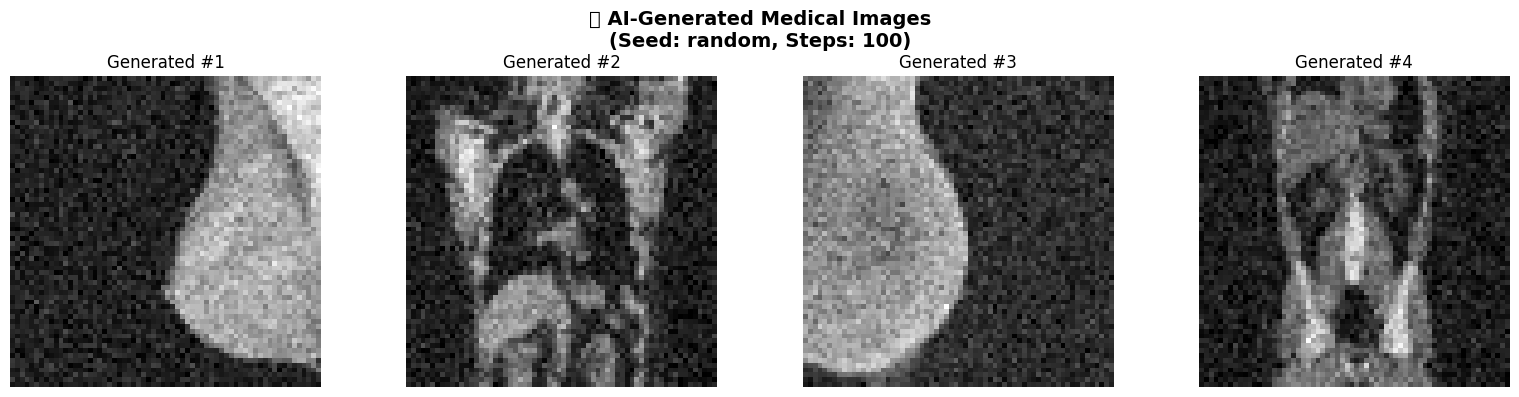

----------------------------------------
✨ Generation complete!

💡 Tips:
   • Change SEED to a number for reproducible results
   • Increase INFERENCE_STEPS for higher quality
   • Set USE_DDIM=False for original quality (slower)


In [18]:
# ============================================
# 🎨 INTERACTIVE IMAGE GENERATOR
# ============================================
# Modify the settings below and run this cell!

# ========== USER SETTINGS ==========
NUM_IMAGES = 4           # Number of images to generate (1-16)
INFERENCE_STEPS = 100    # More steps = better quality but slower (50-1000)
SEED = None              # Set a number for reproducible results, or None for random

# ========== ADVANCED SETTINGS ==========
USE_DDIM = True          # DDIM is faster, DDPM is original scheduler

# =====================================

import torch
from monai.networks.schedulers import DDIMScheduler

def interactive_generate(num_images=4, inference_steps=100, seed=None, use_ddim=True):
    """
    Generate medical images interactively.
    
    Args:
        num_images: Number of images to generate
        inference_steps: Number of denoising steps
        seed: Random seed for reproducibility
        use_ddim: Use DDIM scheduler (faster) or DDPM
    """
    global model
    model.eval()
    
    # Set seed if specified
    if seed is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
        print(f"🎲 Using seed: {seed}")
    
    # Setup scheduler
    if use_ddim:
        gen_scheduler = DDIMScheduler(
            num_train_timesteps=NUM_TRAIN_TIMESTEPS,
            schedule="linear_beta",
        )
        gen_scheduler.set_timesteps(inference_steps)
        print(f"⚡ Using DDIM scheduler with {inference_steps} steps (fast mode)")
    else:
        gen_scheduler = DDPMScheduler(
            num_train_timesteps=NUM_TRAIN_TIMESTEPS,
            schedule="linear_beta",
        )
        gen_scheduler.set_timesteps(NUM_TRAIN_TIMESTEPS)
        print(f"🐢 Using DDPM scheduler with {NUM_TRAIN_TIMESTEPS} steps")
    
    print(f"🖼️  Generating {num_images} medical images...")
    print("-" * 40)
    
    # Generate images
    with torch.no_grad():
        # Use 1 channel to match trained model
        noise = torch.randn(num_images, 1, IMAGE_SIZE, IMAGE_SIZE).to(device)
        image = noise
        
        progress_interval = max(1, len(gen_scheduler.timesteps) // 10)
        
        for i, t in enumerate(gen_scheduler.timesteps):
            if i % progress_interval == 0:
                progress = (i / len(gen_scheduler.timesteps)) * 100
                print(f"  Progress: {progress:.0f}% (step {i}/{len(gen_scheduler.timesteps)})")
            
            model_output = model(image, timesteps=torch.tensor([t] * num_images).to(device))
            image, _ = gen_scheduler.step(model_output, t, image)
        
        print("  Progress: 100% ✅")
        generated = image.cpu()
    
    # Display results
    fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 4))
    if num_images == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        img = generated[i, 0].numpy()  # Single channel grayscale
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        ax.set_title(f"Generated #{i+1}", fontsize=12)
    
    plt.suptitle(f"🏥 AI-Generated Medical Images\n(Seed: {seed if seed else 'random'}, Steps: {inference_steps})", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("-" * 40)
    print("✨ Generation complete!")
    print("\n💡 Tips:")
    print("   • Change SEED to a number for reproducible results")
    print("   • Increase INFERENCE_STEPS for higher quality")
    print("   • Set USE_DDIM=False for original quality (slower)")
    
    return generated

# Run generation with user settings
generated_images = interactive_generate(
    num_images=NUM_IMAGES,
    inference_steps=INFERENCE_STEPS,
    seed=SEED,
    use_ddim=USE_DDIM
)

## 💬 Text Prompt Image Generator

Enter a text prompt below to generate medical images!

> **Note:** This model is an *unconditional* diffusion model trained on CT scans and kidney images. 
> It generates realistic medical images but doesn't truly "understand" text prompts like DALL-E or Stable Diffusion.
> For true text-to-image, you would need to train with a text encoder (like CLIP) and text-image pairs.

💬 TEXT-TO-IMAGE MEDICAL IMAGE GENERATOR

📝 Your Prompt: "Generate a CT scan of a kidney"
------------------------------------------------------------
🔍 Detected keywords: CT Scan, Kidney
⚙️  Quality steps: 150
🖼️  Generating 4 images...
------------------------------------------------------------
🎲 Prompt-based seed: 3056754340
  ▓ 25% complete...
  ▓ 50% complete...
  ▓ 75% complete...
  ▓ 100% complete...

✅ Generation complete!
------------------------------------------------------------


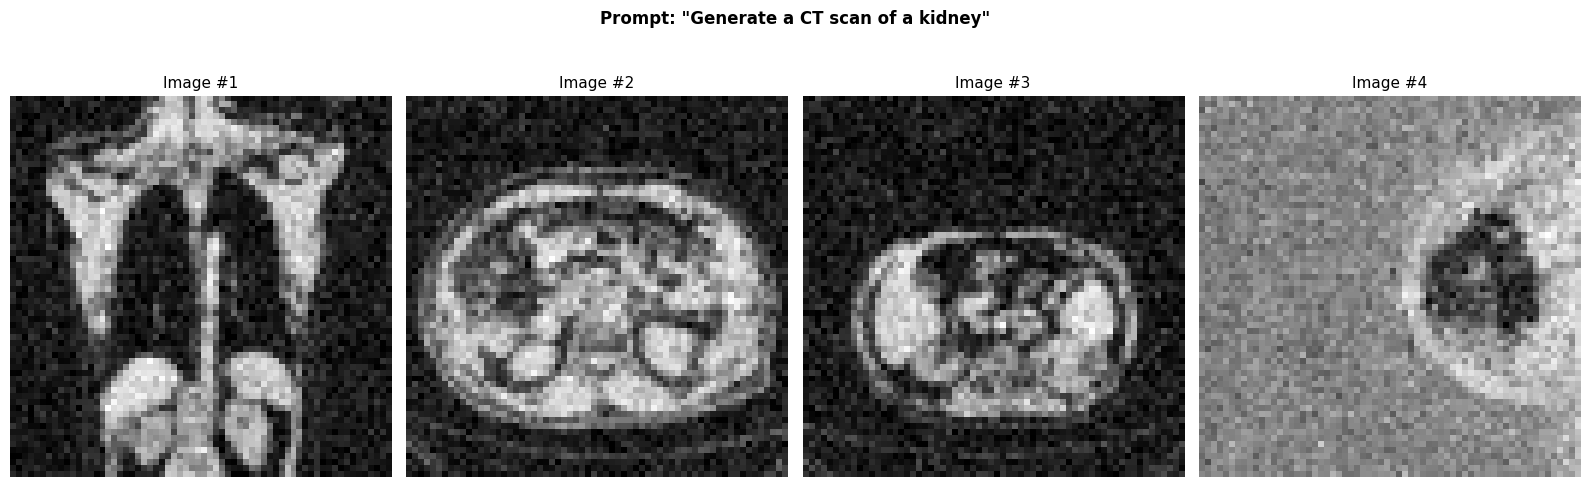


💡 TRY DIFFERENT PROMPTS:
   • 'Generate CT scan of kidney'
   • 'Medical X-ray image'
   • 'High quality diagnostic scan'
   • 'Renal imaging scan'


: 

In [ ]:
# ============================================
# 💬 TEXT PROMPT IMAGE GENERATOR
# ============================================
# Type your prompt below and run this cell!

# ========== ENTER YOUR PROMPT HERE ==========
PROMPT = "Generate a CT scan of a kidney"
# =============================================

# Optional settings
NUM_IMAGES_TO_GENERATE = 4
QUALITY_STEPS = 150  # Higher = better quality (50-500)

# =============================================

import torch
from monai.networks.schedulers import DDIMScheduler

def generate_from_prompt(prompt, num_images=4, steps=150):
    """
    Generate medical images from a text prompt.
    
    Since this is an unconditional model, we parse the prompt for keywords
    and generate images using the trained diffusion model.
    """
    global model
    
    print("=" * 60)
    print("💬 TEXT-TO-IMAGE MEDICAL IMAGE GENERATOR")
    print("=" * 60)
    print(f"\n📝 Your Prompt: \"{prompt}\"")
    print("-" * 60)
    
    # Parse prompt for keywords (for display purposes)
    prompt_lower = prompt.lower()
    detected_keywords = []
    
    if any(word in prompt_lower for word in ['ct', 'scan', 'computed tomography']):
        detected_keywords.append("CT Scan")
    if any(word in prompt_lower for word in ['kidney', 'renal', 'nephro']):
        detected_keywords.append("Kidney")
    if any(word in prompt_lower for word in ['medical', 'clinical', 'diagnostic']):
        detected_keywords.append("Medical Imaging")
    if any(word in prompt_lower for word in ['xray', 'x-ray', 'radiograph']):
        detected_keywords.append("X-Ray")
    if any(word in prompt_lower for word in ['mri', 'magnetic']):
        detected_keywords.append("MRI-style")
    
    if detected_keywords:
        print(f"🔍 Detected keywords: {', '.join(detected_keywords)}")
    else:
        print("🔍 Generating general medical image...")
    
    print(f"⚙️  Quality steps: {steps}")
    print(f"🖼️  Generating {num_images} images...")
    print("-" * 60)
    
    # Use a hash of the prompt as seed for reproducibility
    prompt_seed = hash(prompt) % (2**32)
    torch.manual_seed(prompt_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(prompt_seed)
    print(f"🎲 Prompt-based seed: {prompt_seed}")
    
    model.eval()
    
    # Setup DDIM scheduler for faster generation
    gen_scheduler = DDIMScheduler(
        num_train_timesteps=NUM_TRAIN_TIMESTEPS,
        schedule="linear_beta",
    )
    gen_scheduler.set_timesteps(steps)
    
    # Generate images
    with torch.no_grad():
        noise = torch.randn(num_images, 1, IMAGE_SIZE, IMAGE_SIZE).to(device)
        image = noise
        
        progress_marks = [int(steps * p) for p in [0.25, 0.5, 0.75, 1.0]]
        
        for i, t in enumerate(gen_scheduler.timesteps):
            if i+1 in progress_marks:
                pct = (i+1) / steps * 100
                print(f"  ▓ {pct:.0f}% complete...")
            
            model_output = model(image, timesteps=torch.tensor([t] * num_images).to(device))
            image, _ = gen_scheduler.step(model_output, t, image)
        
        generated = image.cpu()
    
    print("\n✅ Generation complete!")
    print("-" * 60)
    
    # Display results
    fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 5))
    if num_images == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        img = generated[i, 0].numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        ax.set_title(f"Image #{i+1}", fontsize=11)
    
    # Truncate long prompts for title
    display_prompt = prompt if len(prompt) <= 50 else prompt[:47] + "..."
    plt.suptitle(f"Prompt: \"{display_prompt}\"", fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 60)
    print("💡 TRY DIFFERENT PROMPTS:")
    print("   • 'Generate CT scan of kidney'")
    print("   • 'Medical X-ray image'")
    print("   • 'High quality diagnostic scan'")
    print("   • 'Renal imaging scan'")
    print("=" * 60)
    
    return generated

# ============================================
# RUN GENERATION WITH YOUR PROMPT
# ============================================
generated_from_prompt = generate_from_prompt(
    prompt=PROMPT,
    num_images=NUM_IMAGES_TO_GENERATE,
    steps=QUALITY_STEPS
)